In [1]:
import pandas as pd
df = pd.read_csv("customer_churn.csv")
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Contract"] = le.fit_transform(df["Contract"])

df = pd.get_dummies(df, columns=["PaymentMethod"], drop_first=True)

df["PaperlessBilling"] = df["PaperlessBilling"].map({"No":0,"Yes":1})

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df["MinMax"] = MinMaxScaler().fit_transform(df[["MonthlyCharges"]])
df["Standard"] = StandardScaler().fit_transform(df[["MonthlyCharges"]])

In [4]:
Q1 = df["MonthlyCharges"].quantile(.25)
Q3 = df["MonthlyCharges"].quantile(.75)
IQR = Q3-Q1
df["MonthlyCharges"] = df["MonthlyCharges"].clip(Q1-1.5*IQR, Q3+1.5*IQR)

In [9]:
df["CLV"] = df["MonthlyCharges"] * df["Tenure"]
df["AvgSpend"] = df["TotalCharges"]/(df["Tenure"]+1)
df["PaymentEfficiency"] = df["TotalCharges"]/(df["MonthlyCharges"]*df["Tenure"]+1)
df["ChargePerTenure"] = df["MonthlyCharges"]/(df["Tenure"]+1)
df["TenureGroup"] = pd.cut(df["Tenure"], [-1,12,24,48,100],labels=False)


In [10]:
print(df.select_dtypes("number").corr()["Churn"].sort_values())

TenureGroup         -0.597738
Tenure              -0.509208
CLV                 -0.367997
Contract            -0.182759
SeniorCitizen       -0.018114
TotalCharges         0.004250
PaperlessBilling     0.016145
MinMax               0.107381
Standard             0.107381
MonthlyCharges       0.107381
PaymentEfficiency    0.207950
AvgSpend             0.471932
ChargePerTenure      0.589111
Churn                1.000000
Name: Churn, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["Churn","CustomerID"])
y = df["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=.2,random_state=42
)

model = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("model",RandomForestClassifier(random_state=42))
])

model.fit(X_train,y_train)
print(model.score(X_test,y_test))

0.96


In [12]:
print(df.select_dtypes("number").corr()["Churn"].sort_values())

TenureGroup         -0.597738
Tenure              -0.509208
CLV                 -0.367997
Contract            -0.182759
SeniorCitizen       -0.018114
TotalCharges         0.004250
PaperlessBilling     0.016145
MinMax               0.107381
Standard             0.107381
MonthlyCharges       0.107381
PaymentEfficiency    0.207950
AvgSpend             0.471932
ChargePerTenure      0.589111
Churn                1.000000
Name: Churn, dtype: float64


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.96


In [14]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

Tenure                            0.180232
ChargePerTenure                   0.172817
TenureGroup                       0.152623
AvgSpend                          0.086257
Contract                          0.082759
CLV                               0.082456
PaymentEfficiency                 0.064197
MonthlyCharges                    0.043237
Standard                          0.043078
MinMax                            0.035068
TotalCharges                      0.034089
PaperlessBilling                  0.008833
SeniorCitizen                     0.005098
PaymentMethod_Electronic Check    0.004772
PaymentMethod_Credit Card         0.004484
dtype: float64


In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop('Churn', axis=1)
y = df['Churn']

# Only numeric columns
X = X.select_dtypes(include='number')

selector = SelectKBest(f_classif, k=min(10, X.shape[1]))
X_selected = selector.fit_transform(X, y)

print("Selected Features:")
print(X.columns[selector.get_support()].tolist())

Selected Features:
['Tenure', 'MonthlyCharges', 'Contract', 'MinMax', 'Standard', 'CLV', 'AvgSpend', 'PaymentEfficiency', 'ChargePerTenure', 'TenureGroup']


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        84
           1       0.87      0.81      0.84        16

    accuracy                           0.95       100
   macro avg       0.92      0.89      0.90       100
weighted avg       0.95      0.95      0.95       100



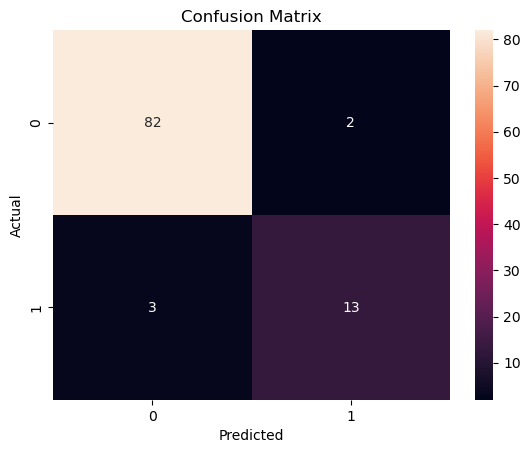

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
print("Sample Predictions:", y_pred[:10])

Sample Predictions: [1 1 0 0 0 0 0 1 0 0]
